# Parcial Primer Corte

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df= pd.read_csv('/content/datos.csv')

In [ ]:
df.head(5)

,Voltaje(V),Campo Electrico (V/m),Desplazamiento (mm),Tiempo caida(s),Velocidad caida (m/s),Radio,Tiempo subida(s),Velocidad subida (mm/s),Carga (Unidades)
0,500,100000,0.002,44.98,0.000044,6.780000e-07,15.76,0.000127,7.130000e-19
1,500,100000,0.002,16.90,0.000118,1.110000e-06,3.05,0.000656,8.860000e-19
2,500,100000,0.002,22.81,0.000088,9.520000e-07,2.66,0.000752,8.620000e-19
3,500,100000,0.002,72.85,0.000028,5.330000e-07,4.41,0.000454,5.910000e-19
4,500,100000,0.002,58.71,0.000034,5.930000e-07,1.70,0.001180,6.450000e-19


**Se pretende ajustar la carga de la gota en funcion de las demas variables de la base de datos**

Se elimina la columna de desplazamiento porque es constante para todas las gotas

In [ ]:
df.shape

(30, 9)

In [ ]:
df.columns

Index(['Voltaje(V)', 'Campo Electrico (V/m)', 'Desplazamiento (mm)',
       'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ',
       'Tiempo  subida(s)', 'Velocidad subida (mm/s)', 'Carga (Unidades)'],
      dtype='object')

In [ ]:
# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

#Como se puede ver la desviacion de las cargas corresponde a la carga electrica de un electron

In [ ]:

# Calcular la varianza de y
varianza_y = np.var(y)

# Calcular la desviación estándar de y
desviacion_estandar_y = np.sqrt(varianza_y)

# Imprimir la desviación estándar de y
print("Desviación estándar de la variable objetivo y:", desviacion_estandar_y)


Desviación estándar de la variable objetivo y: 1.648640820662753e-19


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

####Para este modelo el intercepto no tiene sentido

In [ ]:
# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Realizar k-folds (usaremos k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)


ValueError: ignored

In [ ]:

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)



Función de coste en entrenamiento: 3.830579887689753e-38
Función de coste en prueba: 6.508464288344585e-38
Coeficientes del modelo final: [-1.05999299e-20  5.32942892e-23  5.93236975e-21  2.67749545e-15
  1.58887578e-13 -9.45303345e-21  1.75826073e-16]


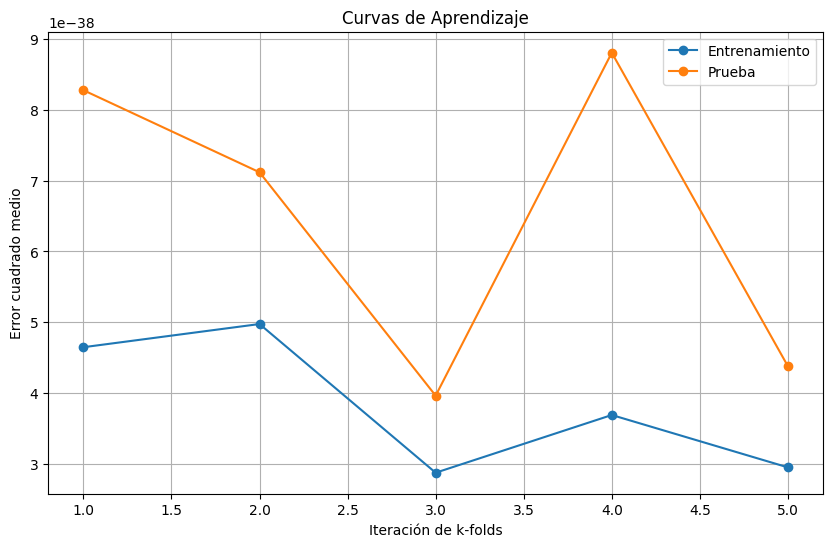

In [ ]:
# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 6), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración de Stratified k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Imprimir los índices de entrenamiento y prueba de cada iteración
for i, (train_index, test_index) in enumerate(zip(train_indices, test_indices)):
    print(f"Iteración {i + 1}:")
    print("Índices de entrenamiento:", train_index)
    print("Índices de prueba:", test_index)
    print()


Iteración 1:
Índices de entrenamiento: [ 1  2  3  4  5  6  7 10 11 13 14 15 16 17 18 19 20 22 23 24 26 27]
Índices de prueba: [ 0  8  9 12 21 25]

Iteración 2:
Índices de entrenamiento: [ 0  2  3  4  5  6  7  8  9 10 12 14 16 18 19 20 21 23 24 25 26 27]
Índices de prueba: [ 1 11 13 15 17 22]

Iteración 3:
Índices de entrenamiento: [ 0  1  6  7  8  9 10 11 12 13 14 15 17 18 19 20 21 22 24 25 26 27]
Índices de prueba: [ 2  3  4  5 16 23]

Iteración 4:
Índices de entrenamiento: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 21 22 23 25]
Índices de prueba: [18 20 24 26 27]

Iteración 5:
Índices de entrenamiento: [ 0  1  2  3  4  5  8  9 11 12 13 15 16 17 18 20 21 22 23 24 25 26 27]
Índices de prueba: [ 6  7 10 14 19]



Función de coste en entrenamiento: 6.4247785606802e-41
Función de coste en prueba: 1.7598358062590689e-40
Coeficientes del modelo final: [-1.99089898e-18  9.94852530e-21  2.07119043e-21 -1.16537696e-14
  2.53720535e-12  2.82502037e-21  2.70929790e-18]


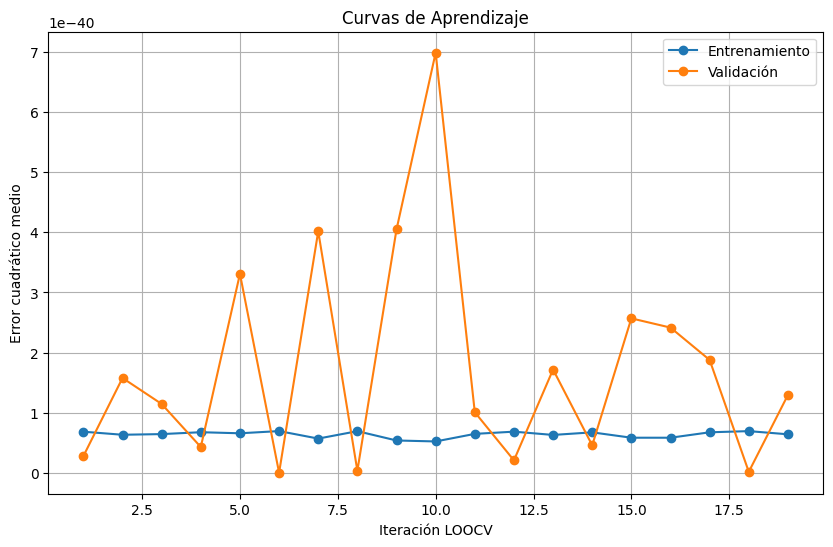

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Inicializar Leave-One-Out Cross-Validation (LOOCV)
loocv = LeaveOneOut()

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

for train_index, test_index in loocv.split(X):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[test_index]

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_val_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_val_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(X) + 1), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, len(X) + 1), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración LOOCV')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


Iteración 1:
Dato de prueba: Voltaje(V)                 4.000000e+02
Campo Electrico (V/m)      8.000000e+04
Desplazamiento (mm)        2.000000e-03
Tiempo  caida(s)           3.082000e+01
Velocidad  caida (m/s)     6.490000e-05
Radio                      8.190000e-07
Tiempo  subida(s)          5.640000e+00
Velocidad subida (mm/s)    3.550000e-04
Carga (Unidades)           1.010000e-18
Name: 0, dtype: float64
Error cuadrático medio: 5.448174950922699e-40

Iteración 2:
Dato de prueba: Voltaje(V)                 4.000000e+02
Campo Electrico (V/m)      8.000000e+04
Desplazamiento (mm)        2.000000e-03
Tiempo  caida(s)           2.581000e+01
Velocidad  caida (m/s)     7.750000e-05
Radio                      8.950000e-07
Tiempo  subida(s)          2.950000e+00
Velocidad subida (mm/s)    6.780000e-04
Carga (Unidades)           1.050000e-18
Name: 1, dtype: float64
Error cuadrático medio: 9.62225947027478e-40

Iteración 3:
Dato de prueba: Voltaje(V)                 4.000000e+02
Campo Electr

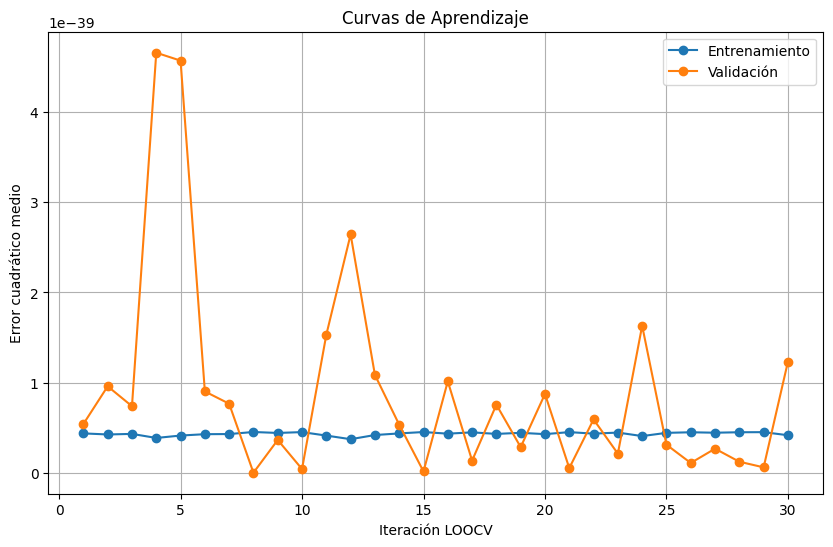

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Inicializar Leave-One-Out Cross-Validation (LOOCV)
loocv = LeaveOneOut()

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

for i, (train_index, test_index) in enumerate(loocv.split(X)):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[test_index]

    # Obtener el dato de prueba actual
    dato_de_prueba = df.iloc[test_index[0]]

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_val_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_val_fold, y_pred_test)
    mse_test_scores.append(mse_test)

    # Imprimir el dato de prueba actual
    print(f"Iteración {i + 1}:")
    print("Dato de prueba:", dato_de_prueba)
    print("Error cuadrático medio:", mse_test)
    print()

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(X) + 1), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, len(X) + 1), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración LOOCV')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


Función de coste en entrenamiento: 4.062478692411689e-40
Función de coste en prueba: 9.22597476198382e-40
Coeficientes del modelo final: [-1.15647960e-18  5.77477562e-21  2.55745542e-21 -1.35975912e-14
  2.94169425e-12  1.61623353e-22 -1.70630758e-17]


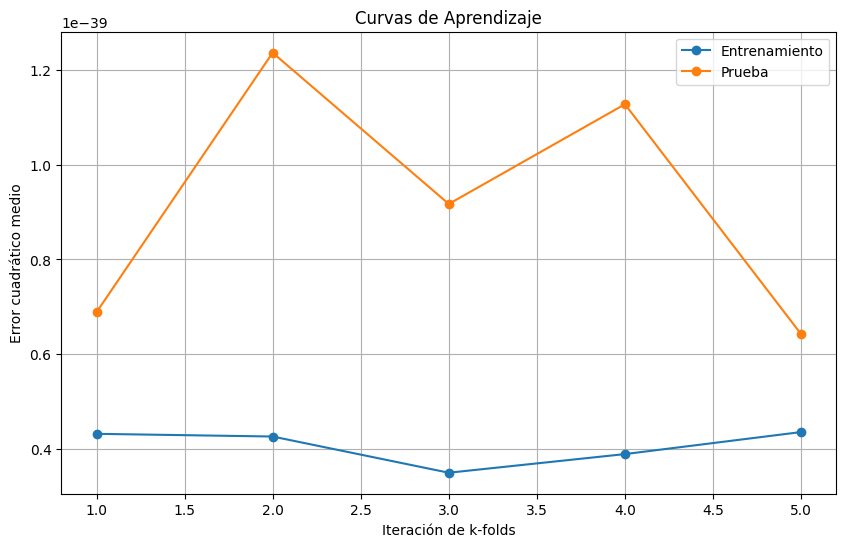

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Realizar k-folds (usaremos k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

for train_index, test_index in kf.split(X):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 6), mse_test_scores, marker='o', label='Prueba')
plt.xlabel('Iteración de k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


Función de coste en entrenamiento: 4.122413546674029e-40
Función de coste en prueba: 8.62403748263923e-40
Coeficientes del modelo final: [-1.15647960e-18  5.77477562e-21  2.55745542e-21 -1.35975912e-14
  2.94169425e-12  1.61623353e-22 -1.70630758e-17]


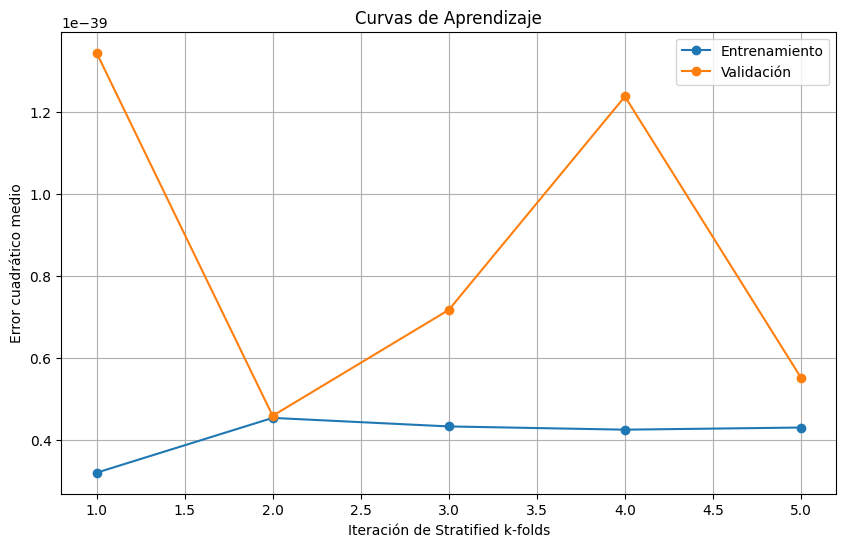

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Obtener las etiquetas de estratificación basadas en los niveles de voltaje
etiquetas_estratificacion = df['Voltaje(V)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Realizar Stratified k-folds (usaremos k=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

for train_index, test_index in skf.split(X, etiquetas_estratificacion):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 6), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración de Stratified k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


Función de coste en entrenamiento: 4.122413546674029e-40
Función de coste en prueba: 8.62403748263923e-40
Coeficientes del modelo final: [-1.15647960e-18  5.77477562e-21  2.55745542e-21 -1.35975912e-14
  2.94169425e-12  1.61623353e-22 -1.70630758e-17]


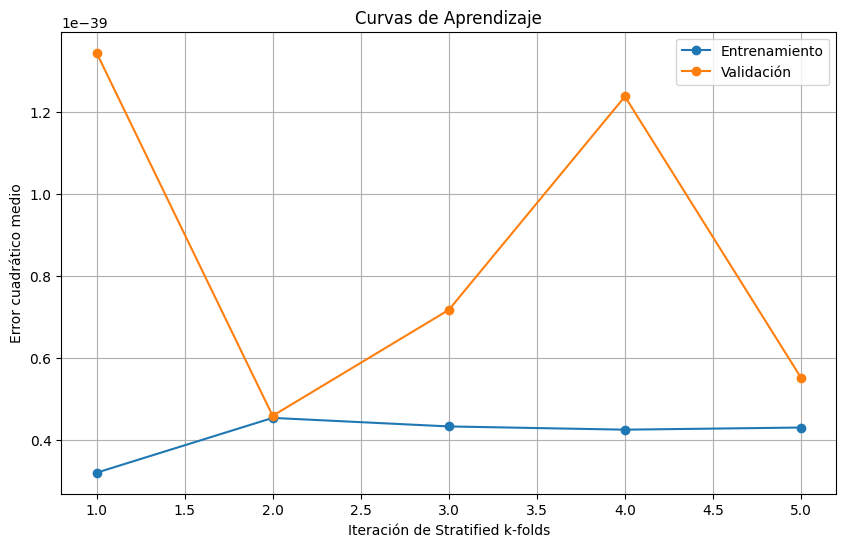

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Obtener las etiquetas de estratificación basadas en los niveles de voltaje
etiquetas_estratificacion = df['Voltaje(V)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Realizar Stratified k-folds (usaremos k=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

# Almacenar conjuntos de entrenamiento y prueba para cada iteración
conjuntos_entrenamiento = []
conjuntos_prueba = []

for train_index, test_index in skf.split(X, etiquetas_estratificacion):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Añadir conjuntos de entrenamiento y prueba a las listas
    conjuntos_entrenamiento.append((X_train_fold, y_train_fold))
    conjuntos_prueba.append((X_test_fold, y_test_fold))

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 6), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración de Stratified k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Supongamos que ya tienes ajustado tu modelo de regresión y lo llamamos 'modelo_regresion'
# También suponemos que tienes tus datos de características en X

# Realiza predicciones en tus datos de características
y_pred = modelo_regresion.predict(X)

# Calcula la varianza de las predicciones
varianza_predicciones = np.var(y_pred)

# Imprime la varianza de las predicciones
print("Varianza de las predicciones:", varianza_predicciones)


Varianza de las predicciones: 2.690797998086165e-38


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Supongamos que ya tienes ajustado tu modelo de regresión y lo llamamos 'modelo_regresion'
# También suponemos que tienes tus datos de características en X

# Realiza predicciones en tus datos de características
y_pred = modelo_regresion.predict(X)

# Calcula la desviación estándar de las predicciones
desviacion_estandar_predicciones = np.std(y_pred)

# Imprime la desviación estándar de las predicciones
print("Desviación estándar de las predicciones:", desviacion_estandar_predicciones)


Desviación estándar de las predicciones: 1.640365202656459e-19


Función de coste en entrenamiento: 3.831873224892704e-40
Función de coste en prueba: 8.68075035658987e-40
Coeficientes del modelo final: [-1.15647960e-18  5.77477562e-21  2.55745542e-21 -1.35975912e-14
  2.94169425e-12  1.61623353e-22 -1.70630758e-17]


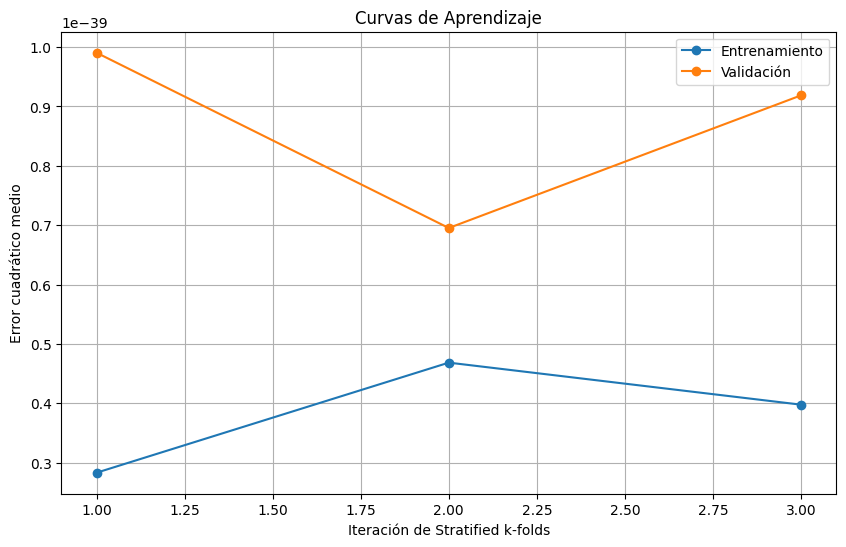

In [181]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Obtener las etiquetas de estratificación basadas en los niveles de voltaje
etiquetas_estratificacion = df['Voltaje(V)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Realizar Stratified k-folds con 3 folds
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

# Almacenar conjuntos de entrenamiento y prueba para cada iteración
conjuntos_entrenamiento = []
conjuntos_prueba = []

for train_index, test_index in skf.split(X, etiquetas_estratificacion):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Añadir conjuntos de entrenamiento y prueba a las listas
    conjuntos_entrenamiento.append((X_train_fold, y_train_fold))
    conjuntos_prueba.append((X_test_fold, y_test_fold))

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, 4), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 4), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración de Stratified k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


Función de coste en entrenamiento: 3.936921679293124e-40
Función de coste en prueba: 8.050908264523925e-40
Coeficientes del modelo final: [-1.15647960e-18  5.77477562e-21  2.55745542e-21 -1.35975912e-14
  2.94169425e-12  1.61623353e-22 -1.70630758e-17]


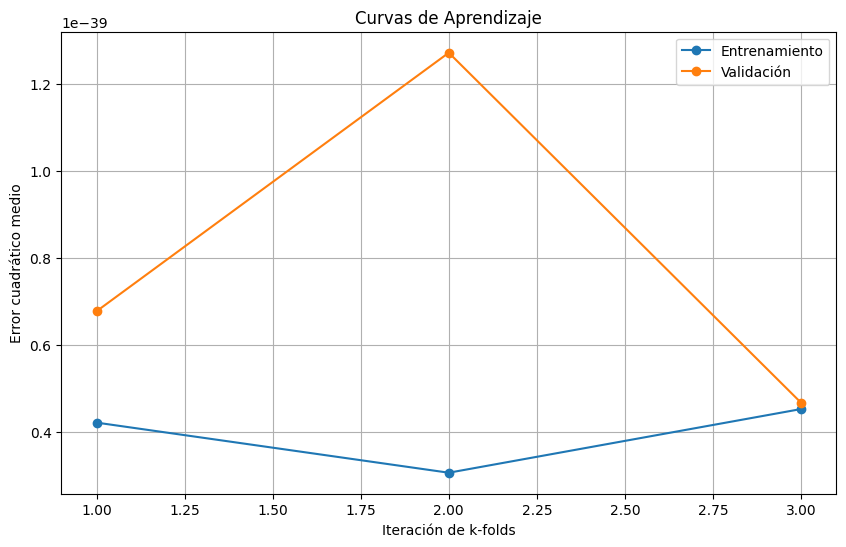

In [192]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Realizar k-folds con 3 folds
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

# Almacenar conjuntos de entrenamiento y prueba para cada iteración
conjuntos_entrenamiento = []
conjuntos_prueba = []

for train_index, test_index in kf.split(X):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Añadir conjuntos de entrenamiento y prueba a las listas
    conjuntos_entrenamiento.append((X_train_fold, y_train_fold))
    conjuntos_prueba.append((X_test_fold, y_test_fold))

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, 4), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 4), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración de k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


Función de coste en entrenamiento: 3.070335286462748e-40
Función de coste en prueba: 9.86826849497711e-40
Coeficientes del modelo final: [-1.15647960e-18  5.77477562e-21  2.55745542e-21 -1.35975912e-14
  2.94169425e-12  1.61623353e-22 -1.70630758e-17]


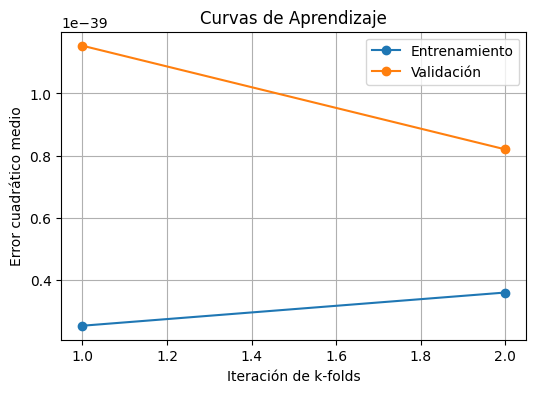

In [184]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Realizar k-folds con 2 folds
kf = KFold(n_splits=2, shuffle=True, random_state=42)

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

# Almacenar conjuntos de entrenamiento y prueba para cada iteración
conjuntos_entrenamiento = []
conjuntos_prueba = []

for train_index, test_index in kf.split(X):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Añadir conjuntos de entrenamiento y prueba a las listas
    conjuntos_entrenamiento.append((X_train_fold, y_train_fold))
    conjuntos_prueba.append((X_test_fold, y_test_fold))

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(6, 4))
plt.plot(range(1, 3), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 3), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración de k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


Función de coste en entrenamiento: 4.098212046047689e-40
Función de coste en prueba: 7.560323607692017e-40
Coeficientes del modelo final: [-1.15647960e-18  5.77477562e-21  2.55745542e-21 -1.35975912e-14
  2.94169425e-12  1.61623353e-22 -1.70630758e-17]


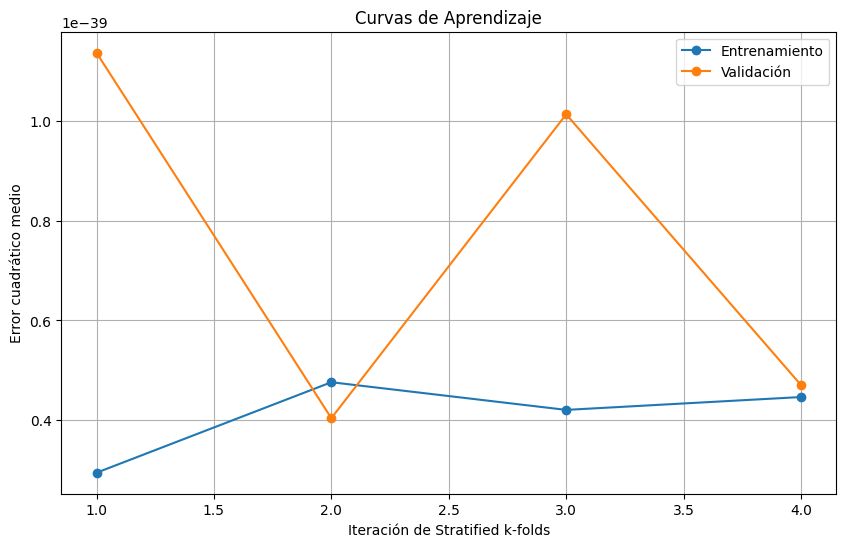

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Obtener las etiquetas de estratificación basadas en los niveles de voltaje
etiquetas_estratificacion = df['Voltaje(V)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Realizar Stratified k-folds con 3 folds
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

# Almacenar conjuntos de entrenamiento y prueba para cada iteración
conjuntos_entrenamiento = []
conjuntos_prueba = []

for train_index, test_index in skf.split(X, etiquetas_estratificacion):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Añadir conjuntos de entrenamiento y prueba a las listas
    conjuntos_entrenamiento.append((X_train_fold, y_train_fold))
    conjuntos_prueba.append((X_test_fold, y_test_fold))

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(range(1, 5), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 5), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración de Stratified k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()

Función de coste en entrenamiento: 4.098212046047689e-40
Función de coste en prueba: 7.560323607692017e-40
Coeficientes del modelo final: [-1.15647960e-18  5.77477562e-21  2.55745542e-21 -1.35975912e-14
  2.94169425e-12  1.61623353e-22 -1.70630758e-17]


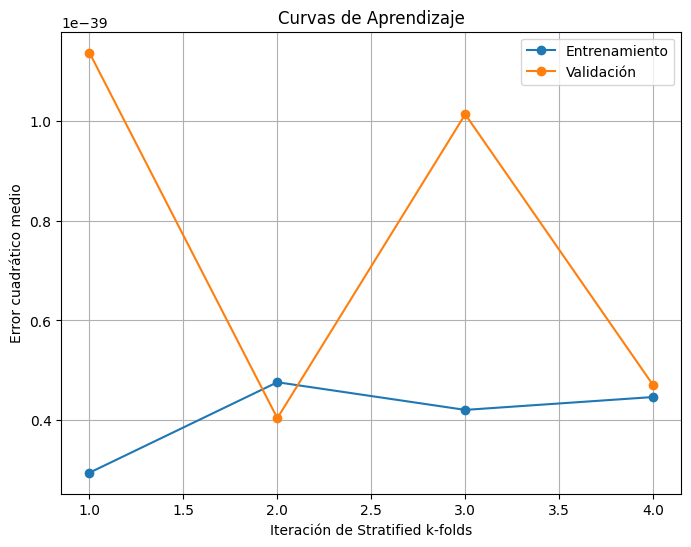

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Obtener las etiquetas de estratificación basadas en los niveles de voltaje
etiquetas_estratificacion = df['Voltaje(V)']

# Fijar el intercepto en 0
modelo_regresion = LinearRegression(fit_intercept=False)

# Realizar Stratified k-folds con 4 folds
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Almacenar los errores cuadrados medios de prueba y entrenamiento en cada iteración
mse_train_scores = []
mse_test_scores = []

# Almacenar conjuntos de entrenamiento y prueba para cada iteración
conjuntos_entrenamiento = []
conjuntos_prueba = []

for train_index, test_index in skf.split(X, etiquetas_estratificacion):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Añadir conjuntos de entrenamiento y prueba a las listas
    conjuntos_entrenamiento.append((X_train_fold, y_train_fold))
    conjuntos_prueba.append((X_test_fold, y_test_fold))

    # Ajustar el modelo a los datos de entrenamiento
    modelo_regresion.fit(X_train_fold, y_train_fold)

    # Predecir en el conjunto de entrenamiento
    y_pred_train = modelo_regresion.predict(X_train_fold)

    # Calcular el error cuadrático medio en el conjunto de entrenamiento
    mse_train = mean_squared_error(y_train_fold, y_pred_train)
    mse_train_scores.append(mse_train)

    # Predecir en el conjunto de prueba
    y_pred_test = modelo_regresion.predict(X_test_fold)

    # Calcular el error cuadrático medio en el conjunto de prueba
    mse_test = mean_squared_error(y_test_fold, y_pred_test)
    mse_test_scores.append(mse_test)

# Calcular la función de coste promedio en cada iteración
coste_train = np.mean(mse_train_scores)
coste_test = np.mean(mse_test_scores)

# Imprimir la función de coste promedio en los conjuntos de entrenamiento y prueba
print("Función de coste en entrenamiento:", coste_train)
print("Función de coste en prueba:", coste_test)

# Ajustar el modelo final con todos los datos de entrenamiento
modelo_regresion_final = LinearRegression(fit_intercept=False)
modelo_regresion_final.fit(X, y)

# Obtener los coeficientes del modelo final
coeficientes = modelo_regresion_final.coef_

# Imprimir los coeficientes del modelo final
print("Coeficientes del modelo final:", coeficientes)

# Trazar las curvas de aprendizaje
plt.figure(figsize=(8, 6))
plt.plot(range(1, 5), mse_train_scores, marker='o', label='Entrenamiento')
plt.plot(range(1, 5), mse_test_scores, marker='o', label='Validación')
plt.xlabel('Iteración de Stratified k-folds')
plt.ylabel('Error cuadrático medio')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


In [190]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tu DataFrame df con los datos
# Asegúrate de haber importado todas las bibliotecas necesarias y de tener tus datos cargados.

# Crear una matriz de características (X) excluyendo "Desplazamiento (mm)"
X = df[['Voltaje(V)', 'Campo Electrico (V/m)', 'Tiempo  caida(s)', 'Velocidad  caida (m/s)', 'Radio ', 'Tiempo  subida(s)', 'Velocidad subida (mm/s)']]

# Crear la variable objetivo (y) que es "Carga (Unidades)"
y = df['Carga (Unidades)']

# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear un modelo de regresión lineal múltiple
modelo = LinearRegression()

# Almacena la función de costo en conjuntos de entrenamiento y prueba durante las iteraciones
cost_train_history = []
cost_test_history = []

# Define una serie de tamaños de conjunto de entrenamiento (evitando 1.0)
train_sizes = np.linspace(0.1, 0.9, 9)  # Cambiado el rango

# Almacena los errores cuadráticos medios en entrenamiento y prueba
train_errors = []
test_errors = []

for train_size in train_sizes:
    # Divide los datos en conjuntos de entrenamiento y prueba con el tamaño actual
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-train_size, random_state=42)

    # Crea y ajusta el modelo de regresión lineal
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    # Calcula el error cuadrático medio en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)


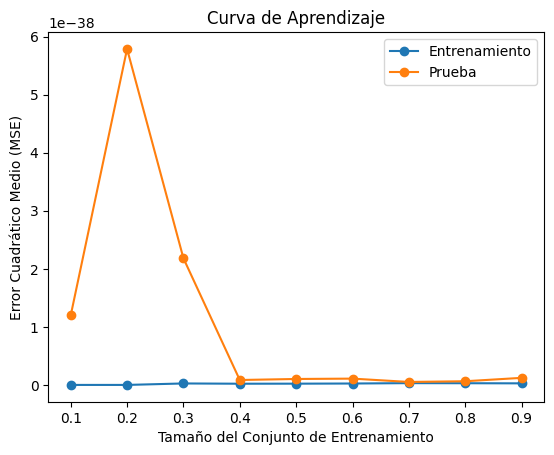

In [191]:
# Grafica la curva de aprendizaje
plt.plot(train_sizes, train_errors, label='Entrenamiento', marker='o')
plt.plot(train_sizes, test_errors, label='Prueba', marker='o')
plt.xlabel('Tamaño del Conjunto de Entrenamiento')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.title('Curva de Aprendizaje')
plt.show()

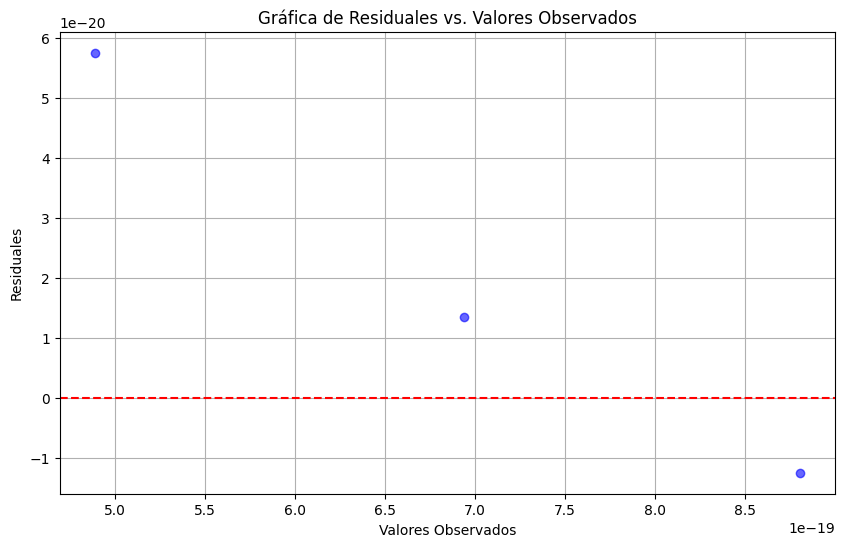

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Supongamos que tienes tus datos y modelo definidos como se muestra en tu pregunta

# Ajustar el modelo de regresión lineal
modelo.fit(X_train, y_train)

# Predecir los valores en el conjunto de prueba
y_pred = modelo.predict(X_test)

# Calcular los residuales restando los valores observados de los valores predichos
residuales = y_test - y_pred

# Crear una gráfica de dispersión de los residuales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuales, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Observados')
plt.ylabel('Residuales')
plt.title('Gráfica de Residuales vs. Valores Observados')
plt.grid(True)
plt.show()


In [194]:
residuales

27    1.347685e-20
15   -1.241439e-20
23    5.758319e-20
Name: Carga (Unidades), dtype: float64